In [1]:
import jax, jax.numpy as jnp
from flax import nnx
from jax import lax
jax.config.update("jax_enable_x64", True)

def cheb_lobatto(N: int):
    j = jnp.arange(N+1, dtype=jnp.float64)
    x = jnp.cos(jnp.pi * j / N)                      # nodes
    # canonical weights for 2nd barycentric form on Lobatto nodes:
    # w_j = (-1)^j * (1/2 at ends, 1 otherwise) — global factor cancels
    delta = jnp.where((j==0) | (j==N), 0.5, 1.0)
    w = ((-1.0) ** j) * delta
    return x, w

def barycentric_lambdas(x, nodes, w, tol=1e-15):
    """Return λ(x) of shape (B,M) for batch x:(B,), nodes/w:(M,). Exact at nodes."""
    x = x.ravel()
    diff = x[:, None] - nodes[None, :]               # (B,M)
    # If x hits a node, return the one-hot exactly
    idx = jnp.argmin(jnp.abs(diff), axis=1)          # (B,)
    hit = jnp.take_along_axis(jnp.abs(diff), idx[:,None], axis=1)[:,0] < tol
    # z = w/(x - x_j)s
    w_values = w()
    z = w_values[None, :] / diff                            # (B,M)
    S = jnp.sum(z, axis=1, keepdims=True)            # (B,1)
    lam = z / S                                      # (B,M)
    # overwrite rows that hit a node with one-hot
    onehot = jax.nn.one_hot(idx, nodes.shape[0], dtype=x.dtype)
    lam = jnp.where(hit[:, None], onehot, lam)
    return lam


def barycentric_lambdas_safe(x, nodes, w):
    """
    Return λ(x) with exact-hit short-circuit, no 1/0 ever computed.
    
    Handles both constant weights (from RationalBaryWeights) and 
    input-dependent weights (from LinearRationalBaryWeights).
    """
    x = x.ravel()
    
    # Get weights - could be constant or input-dependent
    wv = w(x)  # This will be shape (n+1,) for constant weights or (B, n+1) for input-dependent
    
    # Handle both cases: constant weights and input-dependent weights
    if wv.ndim == 1:
        # Constant weights case - broadcast to match batch size
        wv = wv[None, :]  # (1, n+1)
        wv = jnp.broadcast_to(wv, (x.shape[0], nodes.shape[0]))  # (B, n+1)
    elif wv.ndim == 2:
        # Input-dependent weights case - already correct shape (B, n+1)
        pass
    else:
        raise ValueError(f"Expected weights to be 1D or 2D, got shape {wv.shape}")

    def row(i):
        xi = x[i]
        wi = wv[i]  # weights for this specific input
        diff = xi - nodes
        k = jnp.argmin(jnp.abs(diff))
        hit = (diff[k] == 0.0)  # exact equality in FP64 at endpoints

        def on_hit(_):
            # r(x_j) = f_j ⇒ λ is one-hot; ensure zero gradient w.r.t. w
            return lax.stop_gradient(jax.nn.one_hot(k, nodes.shape[0], dtype=xi.dtype))

        def off_hit(_):
            z = wi / diff                      # safe: no zero entries in diff here
            S = jnp.sum(z)
            return z / S

        return lax.cond(hit, on_hit, off_hit, operand=None)

    return jax.vmap(row)(jnp.arange(x.shape[0]))

In [2]:
DTYPE = jnp.float64

def init_theta_for_bary_weights(n: int, dtype=DTYPE) -> jnp.ndarray:
    delta = jnp.ones(n + 1, dtype=dtype).at[0].set(0.5).at[n].set(0.5)
    theta = jnp.log(delta)  # shape [n+1]
    return theta

def realize_weights_from_theta(theta: jnp.ndarray, *, s: jnp.ndarray) -> jnp.ndarray:
    theta = theta.astype(DTYPE)
    s = s.astype(DTYPE)
    return s * jnp.exp(theta - jnp.mean(theta))

# ------------------------------------------
# Optional: add a single scalar alpha so that
# w_j = alpha * s_j * exp(theta_j - mean(theta))
# Choosing alpha = geometric_mean(delta) makes w EXACTLY w*
# ------------------------------------------
def alpha_to_match_exact(delta: jnp.ndarray) -> DTYPE:
    return jnp.exp(jnp.mean(jnp.log(delta))).astype(DTYPE)

# -------------------------
# Flax-nnx module (optional)
# -------------------------
class RationalBaryWeights(nnx.Module):
    """
    Stores trainable theta and an optional log_alpha that collectively
    produce barycentric weights via:
       w = s * exp(theta - mean(theta))             (no alpha)
       w = exp(log_alpha) * s * exp(theta - mean(theta))   (with alpha)
    """
    theta: nnx.Param
    log_alpha: DTYPE | None
    s: jnp.ndarray        # fixed sign pattern (-1)^j
    use_alpha: bool

    def __init__(self, n: int, *, use_alpha: bool = False, rngs: nnx.Rngs = nnx.Rngs(0)):
        theta0 = init_theta_for_bary_weights(n)        # log(delta)
        self.theta = nnx.Param(theta0)
        self.use_alpha = use_alpha
        self.s = (-1.0) ** jnp.arange(n + 1, dtype=DTYPE)
        if use_alpha:
            delta = jnp.ones(n + 1, dtype=DTYPE).at[0].set(0.5).at[n].set(0.5)
            alpha0 = alpha_to_match_exact(delta)       # geometric mean of delta
            self.log_alpha = jnp.log(alpha0)
        else:
            self.log_alpha = None

    def weights(self, xs) -> jnp.ndarray:
        w = realize_weights_from_theta(self.theta.value, s=self.s)
        if self.use_alpha:
            w = jnp.exp(self.log_alpha) * w
        return w
    
    def __call__(self, xs):
        return self.weights(xs)

class LinearRationalBaryWeights(nnx.Module):
    """
    Stores trainable theta, A matrix, and optional log_alpha that collectively
    produce input-dependent barycentric weights via:
       w(x) = A * x + s * exp(theta - mean(theta))             (no alpha)
       w(x) = A * x + exp(log_alpha) * s * exp(theta - mean(theta))   (with alpha)
    where A is initialized to zero matrix and w is parameterized like RationalBaryWeights
    """
    theta: nnx.Param
    A: nnx.Param          # input-dependent weight matrix
    log_alpha: DTYPE | None
    s: jnp.ndarray        # fixed sign pattern (-1)^j
    use_alpha: bool

    def __init__(self, n: int, *, use_alpha: bool = False, rngs: nnx.Rngs = nnx.Rngs(0)):
        theta0 = init_theta_for_bary_weights(n)        # log(delta)
        self.theta = nnx.Param(theta0)
        # Initialize A to zero matrix (n+1 weights, 1 input dimension)
        self.A = nnx.Param(jnp.zeros((n + 1, 1), dtype=DTYPE))
        self.use_alpha = use_alpha
        self.s = (-1.0) ** jnp.arange(n + 1, dtype=DTYPE)
        if use_alpha:
            delta = jnp.ones(n + 1, dtype=DTYPE).at[0].set(0.5).at[n].set(0.5)
            alpha0 = alpha_to_match_exact(delta)       # geometric mean of delta
            self.log_alpha = jnp.log(alpha0)
        else:
            self.log_alpha = None

    def weights(self, xs) -> jnp.ndarray:
        """
        Compute input-dependent weights w(x) = A * x + w_base
        xs: input of shape (B,) or (B, 1)
        returns: weights of shape (B, n+1) where each row is weights for one input
        """
        xs = jnp.asarray(xs, dtype=DTYPE)
        if xs.ndim == 1:
            xs = xs[:, None]  # (B, 1)
        
        # Base weights (constant part)
        w_base = realize_weights_from_theta(self.theta.value, s=self.s)
        if self.use_alpha:
            w_base = jnp.exp(self.log_alpha) * w_base
        
        # Input-dependent part: A @ x for each input in batch
        linear_part = xs @ self.A.value.T  # (B, 1) @ (1, n+1) = (B, n+1)
        
        # Combine: w(x) = A*x + w_base
        weights = linear_part + w_base[None, :]  # broadcast w_base to (B, n+1)
        
        return weights
    
    def __call__(self, xs):
        return self.weights(xs)

class KernelRationalBaryWeights(nnx.Module):
    """
    Produces purely input-dependent barycentric weights via:
       w(x) = A * x
    where A can be initialized with different strategies.
    No bias term is used - this is a pure kernel approach.
    """
    A: nnx.Param          # input-dependent weight matrix

    def __init__(self, n: int, *, 
                 init_strategy: str = "zeros",
                 init_scale: float = 1e-3,
                 rngs: nnx.Rngs = nnx.Rngs(0)):
        """
        Initialize the A matrix with different strategies:
        - "zeros": Initialize to zero matrix (default)
        - "normal": Initialize with small random normal values  
        - "uniform": Initialize with small random uniform values
        - "xavier": Initialize with Xavier/Glorot initialization
        - "he": Initialize with He initialization
        - "orthogonal": Initialize with orthogonal matrix (scaled down)
        - "identity": Initialize close to identity (for single input case)
        """
        shape = (n + 1, 1)  # (n+1 weights, 1 input dimension)
        
        if init_strategy == "zeros":
            A_init = jnp.zeros(shape, dtype=DTYPE)
        elif init_strategy == "normal":
            A_init = jax.random.normal(rngs(), shape, dtype=DTYPE) * init_scale
        elif init_strategy == "uniform":
            A_init = jax.random.uniform(rngs(), shape, dtype=DTYPE, minval=-init_scale, maxval=init_scale)
        elif init_strategy == "xavier":
            # Xavier/Glorot initialization: scale by sqrt(6/(fan_in + fan_out))
            fan_in, fan_out = shape[1], shape[0]
            limit = jnp.sqrt(6.0 / (fan_in + fan_out)) * init_scale
            A_init = jax.random.uniform(rngs(), shape, dtype=DTYPE, minval=-limit, maxval=limit)
        elif init_strategy == "he":
            # He initialization: scale by sqrt(2/fan_in)
            fan_in = shape[1]
            std = jnp.sqrt(2.0 / fan_in) * init_scale
            A_init = jax.random.normal(rngs(), shape, dtype=DTYPE) * std
        elif init_strategy == "orthogonal":
            # Orthogonal initialization (scaled down)
            if shape[0] >= shape[1]:
                # More rows than columns
                full_matrix = jax.random.normal(rngs(), shape, dtype=DTYPE)
                q, _ = jnp.linalg.qr(full_matrix)
                A_init = q * init_scale
            else:
                # More columns than rows - take transpose, QR, then transpose back
                full_matrix = jax.random.normal(rngs(), (shape[1], shape[0]), dtype=DTYPE)
                q, _ = jnp.linalg.qr(full_matrix)
                A_init = q.T * init_scale
        elif init_strategy == "identity":
            # Identity-like initialization (only works well for square matrices)
            A_init = jnp.eye(shape[0], shape[1], dtype=DTYPE) * init_scale
        else:
            raise ValueError(f"Unknown initialization strategy: {init_strategy}")
        
        self.A = nnx.Param(A_init)

    def weights(self, xs) -> jnp.ndarray:
        """
        Compute purely input-dependent weights w(x) = A * x
        xs: input of shape (B,) or (B, 1)  
        returns: weights of shape (B, n+1) where each row is weights for one input
        """
        xs = jnp.asarray(xs, dtype=DTYPE)
        if xs.ndim == 1:
            xs = xs[:, None]  # (B, 1)
        
        # Pure kernel approach: w(x) = A * x
        weights = xs @ self.A.value.T  # (B, 1) @ (1, n+1) = (B, n+1)
        
        return weights
    
    def __call__(self, xs):
        return self.weights(xs)

In [3]:
class BarycentricAttention(nnx.Module):
    """Single-head barycentric attention over fixed keys (nodes) and weights."""
    nodes: jnp.ndarray | nnx.Param  # shape (M,)
    w: jnp.ndarray | RationalBaryWeights | LinearRationalBaryWeights | KernelRationalBaryWeights
    # Optional: make values trainable; or pass them at call-time.
    V: nnx.Param | None = None  # shape (M,D) if used (constant values)
    # Input-dependent values: V(x) = V_matrix * x + V_bias
    V_matrix: nnx.Param | None = None  # shape (M, D, 1) for input-dependent values
    V_bias: nnx.Param | None = None    # shape (M, D) for input-dependent values
    input_dependent_values: bool = False
    # Query learning parameters
    W: nnx.Param | None = None  # shape (query_hdim, 1) for query transformation
    a: nnx.Param | None = None  # shape (query_hdim, 1) for query transformation
    learn_query: bool = False

    def __init__(self, nodes, w, V_init=None, *, 
                 learn_nodes: bool = False, 
                 input_dependent_values: bool = False,
                 learn_query: bool = False,
                 query_hdim: int = 8,
                 rngs: nnx.Rngs = nnx.Rngs(0)):
        if learn_nodes:
            self.nodes = nnx.Param(jnp.asarray(nodes, dtype=jnp.float64))
        else:
            self.nodes = jnp.asarray(nodes, dtype=jnp.float64)

        if isinstance(w, (RationalBaryWeights, LinearRationalBaryWeights, KernelRationalBaryWeights)):
            self.w = w 
        else:
            self.w = lambda x: jnp.asarray(w, dtype=jnp.float64)
            
        self.input_dependent_values = input_dependent_values
        self.learn_query = learn_query
        
        if V_init is not None:
            V_init = jnp.asarray(V_init, dtype=nodes.dtype)
            if input_dependent_values:
                # Input-dependent values: V(x) = V_matrix * x + V_bias
                # V_bias initialized to V_init, V_matrix initialized to zeros
                self.V_bias = nnx.Param(V_init)  # shape (M, D)
                M, D = V_init.shape
                self.V_matrix = nnx.Param(jnp.zeros((M, D, 1), dtype=nodes.dtype))  # shape (M, D, 1)
                self.V = None  # Not used in input-dependent mode
            else:
                # Constant values (original behavior)
                self.V = nnx.Param(V_init)
                self.V_bias = None
                self.V_matrix = None
        
        # Query learning parameters
        if learn_query:
            self.W = nnx.Param(jnp.identity(query_hdim, dtype=DTYPE)[:,0].reshape(-1,1))
            self.a = nnx.Param(jnp.identity(query_hdim, dtype=DTYPE)[:,0].reshape(-1,1))
        else:
            self.W = None
            self.a = None

    def __call__(self, x):
        """
        x: (B,) or (B,1)
        returns: (B,D)
        """
        x = jnp.asarray(x, dtype=self.nodes.dtype)
        
        if self.learn_query:
            # Transform input to create query
            query = (x @ self.W.T @ self.a).ravel()
            lam = barycentric_lambdas_safe(query, self.nodes, self.w)  # (B,M)
        else:
            # Use input directly as query
            x_ravel = x.ravel()
            lam = barycentric_lambdas_safe(x_ravel, self.nodes, self.w)  # (B,M)
        
        if self.input_dependent_values:
            # Compute input-dependent values: V(x) = V_matrix * x + V_bias
            # Use original x for computing values, not the transformed query
            x_for_values = x.ravel()  # (B,)
            x_batch = x_for_values[:, None, None, None]  # (B, 1, 1, 1)
            
            # V_matrix: (M, D, 1), x_batch: (B, 1, 1, 1) 
            # We want: (B, M, D) where each (m,d) element is V_matrix[m,d,0] * x[b]
            V_linear = self.V_matrix.value[None, :, :, :] * x_batch  # (1, M, D, 1) * (B, 1, 1, 1) -> (B, M, D, 1)
            V_linear = V_linear.squeeze(-1)  # (B, M, D)
            
            V_values = V_linear + self.V_bias.value[None, :, :]  # (B, M, D) + (1, M, D) -> (B, M, D)
            
            # Apply barycentric weights: lam is (B, M), V_values is (B, M, D)
            # We want: sum over M of lam[b,m] * V_values[b,m,d] for each b,d
            result = jnp.einsum('bm,bmd->bd', lam, V_values)  # (B, D)
            return result
        else:
            # Original constant values behavior
            return lam @ self.V.value  # (B,M) @ (M,D) -> (B,D)

In [4]:
class MLP(nnx.Module):
    def __init__(self, layer_sizes: list[int], activation,  *, rngs: nnx.Rngs = nnx.Rngs(0)):
        layers = []
        if activation == "sigmoid":
            activation = lambda x: 2 * nnx.sigmoid(x) - 1
        for i in range(len(layer_sizes) - 2):
            layer = nnx.Linear(layer_sizes[i], layer_sizes[i + 1], rngs=rngs, param_dtype=DTYPE)# , kernel_init = nnx.initializers.zeros_init()
            layers.append(layer)
            layers.append(activation)
        layers.append(nnx.Linear(layer_sizes[-2], layer_sizes[-1], rngs=rngs, param_dtype=DTYPE))# , kernel_init=nnx.initializers.zeros_init()
        self.layers = nnx.Sequential(*layers)
        

    def __call__(self, x: jnp.ndarray):
        x = self.layers(x)
        return x
    
class mini_transformer(nnx.Module):
    def __init__(self, mlp, bary_attention, *, rngs: nnx.Rngs = nnx.Rngs(0)):
        self.mlp = mlp
        self.bary_attention = bary_attention
        # self.norm = nnx.LayerNorm(num_features = 1, dtype = DTYPE, param_dtype = DTYPE, rngs = rngs)

    def __call__(self, x: jnp.ndarray):
        x = self.bary_attention(x)
        res_x = x#self.norm(x)
        res_x = self.mlp(res_x)
        return x + res_x #(1 - self.alpha) * x + self.alpha * res_x # residual connection
    

class mini_fno(nnx.Module):
    def __init__(self, mlp, bary_attention, *, rngs: nnx.Rngs = nnx.Rngs(0)):
        self.mlp = mlp
        self.bary_attention = bary_attention
        # self.norm = nnx.LayerNorm(num_features = 1, dtype = DTYPE, param_dtype = DTYPE, rngs = rngs)

    def __call__(self, x: jnp.ndarray):
        mlp_out = self.mlp(x)
        bary_out = self.bary_attention(x)
        return mlp_out + bary_out

In [5]:
N = 64
nodes, w = cheb_lobatto(N)
f = lambda x: jnp.sin(2 * jnp.pi *8.0 * x)                 # target
y = f(nodes)[:, None]                          # values as (M,1)
w = RationalBaryWeights(N, use_alpha=True)  # trainable weights
bar_attn = BarycentricAttention(nodes, w, V_init=y, rngs=nnx.Rngs(0))
xs = jnp.linspace(-1, 1, 1001).reshape(-1,1)  # (1001,1)
pred = bar_attn(xs)                     # exact Chebyshev–Lobatto interpolant of f


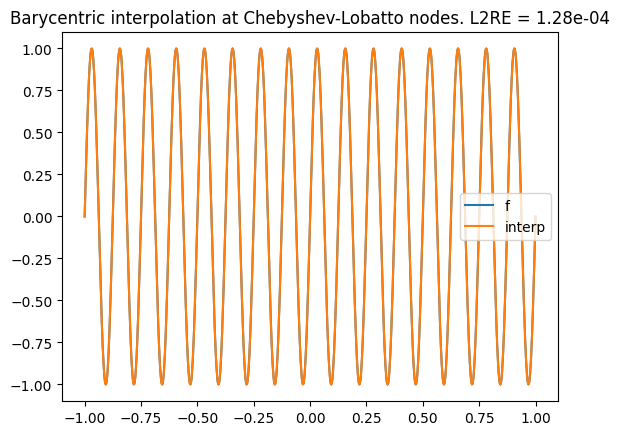

In [6]:
import matplotlib.pyplot as plt
plt.plot(xs, f(xs), label="f")
plt.plot(xs, pred, label="interp")
plt.title(f"Barycentric interpolation at Chebyshev-Lobatto nodes. L2RE = {jnp.linalg.norm(pred-f(xs))/jnp.linalg.norm(f(xs)):.2e}")
plt.legend()
plt.show()

In [7]:
# Training utilities adapted from Softmax_difference.ipynb
import optax
from tqdm import tqdm
from jaxpi.ssbroyden_optax import scale_by_ssbroyden_wolfe_oracle

DTYPE = jnp.float64

# Target functions
def f_sin(x: jnp.ndarray, k: int) -> jnp.ndarray:
    """Sine function: sin(2πkx)"""
    return jnp.sin(2.0 * DTYPE(k) * jnp.pi * x)

def f_tan(x: jnp.ndarray) -> jnp.ndarray:
    """Tangent function: tan(x) over [-1,1]"""
    return jnp.tan(x)

def get_target_function(func_type: str, k: int = 1):
    """Get the target function and its name"""
    if func_type == "sin":
        return lambda x: f_sin(x, k), f"sin(2π{k}x)"
    elif func_type == "tan":
        return f_tan, "tan(x)"
    else:
        raise ValueError(f"Unknown function type: {func_type}. Use 'sin' or 'tan'")

def error_metrics(y_hat: jnp.ndarray, y_true: jnp.ndarray):
    err = jnp.abs(y_hat - y_true)
    rmse = jnp.sqrt(jnp.mean((y_hat - y_true) ** 2))
    linf = jnp.max(err)
    return rmse, linf

# Training functions
def loss_fn(model, x: jnp.ndarray, y: jnp.ndarray):
    y_hat = model(x)
    return jnp.mean((y_hat - y) ** 2)

def rel_l2_error(model, x_eval, y_eval):
    y_hat = model(x_eval)
    return jnp.linalg.norm(y_hat - y_eval) / jnp.linalg.norm(y_eval)

@nnx.jit
def train_step(model, optimizer: nnx.Optimizer, x: jnp.ndarray, y: jnp.ndarray):
    loss, grads = nnx.value_and_grad(loss_fn)(model, x, y)
    optimizer = optimizer.update(model, grads)
    return loss, grads

In [8]:
# SSBroyden training experiment
def run_experiment_broyden(
    N: int = 32,  # Degree of Chebyshev-Lobatto nodes (N+1 nodes)
    k: int = 3,   # Frequency parameter for sin(2πkx)
    # training
    steps: int = 5000, 
    n_train: int = 1024,
    n_eval: int = 2048,
    *,
    func_type: str = "sin",  # "sin" or "tan" - which target function to use
    use_exact_init: bool = True,  # Initialize with exact function values at nodes using the second barycentric form
    use_trainable_weights: bool = True,  # Use trainable barycentric weights,
    rational_representation: str = "standard",  # "standard", "linear", or "kernel" - which weight representation to use
    kernel_init_strategy: str = "normal",  # Initialization strategy for KernelRationalBaryWeights
    kernel_init_scale: float = 1e-3,  # Scale for kernel initialization
    input_dependent_values: bool = False,  # Whether to make values input-dependent: V(x) = V_matrix * x + V_bias
    learn_nodes: bool = False,  # Whether to make nodes trainable
    add_mlp: bool = False,  # Whether to add an MLP after barycentric attention
    learn_query: bool = False, # Whether to learn query transformation
    query_hdim: int = 8, # Hidden dimension of query transformation if used
    hdim: int = 32,  # Hidden dimension of MLP if used
    rng: nnx.Rngs = nnx.Rngs(0),
):
    # Get target function
    target_func, func_name = get_target_function(func_type, k)
    
    print(f"Training Barycentric Attention with N={N} nodes, target={func_name}")
    print(f"Using {rational_representation} rational representation")
    if rational_representation == "kernel":
        print(f"Kernel initialization: {kernel_init_strategy} with scale {kernel_init_scale}")
    if input_dependent_values:
        print("Using input-dependent values: V(x) = V_matrix * x + V_bias")
    if learn_query:
        print(f"Using query learning with hdim={query_hdim}")
    
    # Training and evaluation grids
    x_train = jnp.linspace(-1.0, 1.0, n_train, dtype=DTYPE).reshape(-1, 1)
    y_train = target_func(x_train).reshape(-1, 1)

    x_eval = jnp.linspace(-1.0, 1.0, n_eval, dtype=DTYPE).reshape(-1, 1)
    y_eval = target_func(x_eval).reshape(-1, 1)

    # Create Chebyshev-Lobatto nodes and barycentric weights
    nodes, w = cheb_lobatto(N)
    
    # Initialize nodal values
    if use_exact_init:
        V_init = target_func(nodes)[:, None]  # Exact interpolant initialization
        print(f"Using exact function values for {func_name} initialization")
        
    else:
        V_init = jax.random.normal(rng(), (nodes.shape[0], 1), dtype=DTYPE) * 0.1
        print("Using random initialization")

    # if func_type == "tan":
    #     nodes = nodes.at[0].set(-jnp.pi/2).at[-1].set(jnp.pi/2.)  # Adjust endpoints for tan(x)
    
    
    # Create model
    if use_trainable_weights:
        if rational_representation == "standard":
            w = RationalBaryWeights(N, use_alpha=True)
        elif rational_representation == "linear":
            w = LinearRationalBaryWeights(N, use_alpha=True)
        elif rational_representation == "kernel":
            w = KernelRationalBaryWeights(N, 
                                        init_strategy=kernel_init_strategy,
                                        init_scale=kernel_init_scale,
                                        rngs=rng)
        else:
            raise ValueError(f"Unknown rational representation: {rational_representation}. Use 'standard', 'linear', or 'kernel'")

    # Create barycentric attention with unified interface
    bary_attention = BarycentricAttention(nodes, w, V_init=V_init, 
                                        learn_nodes=learn_nodes,
                                        input_dependent_values=input_dependent_values,
                                        learn_query=learn_query,
                                        query_hdim=query_hdim,
                                        rngs=rng)

    if add_mlp:
        mlp = MLP([1, hdim, 1], activation="sigmoid", rngs=rng)
        model = mini_transformer(mlp, bary_attention, rngs=rng)
    else:
        model = bary_attention

    plt.plot(x_eval, model(x_eval), 'o', label='Initial nodal initialization')
    plt.plot(x_eval, y_eval, label=f'Target function: {func_name}')
    plt.title(f'Initial Nodal Values vs Target Function: {func_name}')
    plt.legend()
    plt.show()

    # Save initial model for comparison
    init_graphdef, init_state = nnx.split(model)
    init_model = nnx.merge(init_graphdef, init_state)

    # Create the SSBroyden optimizer pipeline
    def make_fg_oracle(graphdef, base_state):
        """Oracle f(params, x, y) that rebuilds the model and stamps in `params` arrays."""
        base_state_pure = nnx.freeze(nnx.pure(base_state))  # pure arrays FlatState

        def f(params, x, y):
            # 1) reconstruct Node from the static graph + base state
            node = nnx.merge(graphdef, base_state_pure)
            # 2) stamp the param arrays into the live Node (structure must match nnx.Param tree)
            nnx.update(node, params)
            # 3) compute loss
            return loss_fn(node, x, y)

        return nnx.jit(nnx.value_and_grad(f, argnums=0))

    tx = scale_by_ssbroyden_wolfe_oracle(lr=1.0, c1=1e-4, c2=0.9, max_ls=80)

    # Wrap with the NNX optimizer
    optim = nnx.Optimizer(model, tx, wrt=nnx.Param)

    # Build the oracle once from a static graphdef
    graphdef, base_state = nnx.split(model)
    base_state = nnx.freeze(nnx.pure(base_state))
    fg_oracle = make_fg_oracle(graphdef, base_state)

    print(x_train.shape)
    @nnx.jit
    def train_step_b(model, opt, x, y):
        # grads w.r.t. model Params
        def cur_loss(m): return loss_fn(m, x, y)
        f_k, grads = nnx.value_and_grad(cur_loss, argnums=nnx.DiffState(0, nnx.Param))(model)

        # Pass oracle + runtime tensors via **kwargs (forwarded to tx.update)
        
        return f_k, grads

    # Training loop
    pbar = tqdm(range(steps), desc="training")
    initial_error = rel_l2_error(model, x_eval, y_eval)
    print(f"Initial eval rel L2: {initial_error}")
    
    for i in pbar:
        loss, grads = train_step_b(model, optim, x_train, y_train)
        if i % 100 == 0:
            eval_error = rel_l2_error(model, x_eval, y_eval)
            pbar.set_description(f"step {i}, train loss={loss:.3e}, eval rel L2={eval_error:.3e}")
    
    final_error = rel_l2_error(model, x_eval, y_eval)
    print(f"Final eval rel L2: {final_error}")
    
    return model, init_model, grads

In [9]:
# Adam/SGD training experiment for comparison
def run_experiment_adam(
    N: int = 32,  # Degree of Chebyshev-Lobatto nodes (N+1 nodes)
    k: int = 3,   # Frequency parameter for sin(2πkx)
    # training
    steps: int = 10000,
    n_train: int = 1024,
    n_eval: int = 2048,
    lr: float = 1e-3,
    *,
    func_type: str = "sin",  # "sin" or "tan" - which target function to use
    use_exact_init: bool = False,  # Initialize with exact function values at nodes
    optimizer_type: str = "adam",  # "adam" or "sgd"
    use_trainable_weights: bool = True,  # Use trainable barycentric weights
    rational_representation: str = "standard",  # "standard", "linear", or "kernel" - which weight representation to use
    kernel_init_strategy: str = "normal",  # Initialization strategy for KernelRationalBaryWeights
    kernel_init_scale: float = 1e-3,  # Scale for kernel initialization
    input_dependent_values: bool = False,  # Whether to make values input-dependent: V(x) = V_matrix * x + V_bias
    learn_nodes: bool = False,  # Whether to make nodes trainable
    add_mlp: bool = False,  # Whether to add an MLP after barycentric attention
    learn_query: bool = False, # Whether to learn query transformation
    query_hdim: int = 8, # Hidden dimension of query transformation if used
    hdim: int = 32,  # Hidden dimension of MLP if used
    rng: nnx.Rngs = nnx.Rngs(0),
):
    # Get target function
    target_func, func_name = get_target_function(func_type, k)
    
    print(f"Training Barycentric Attention with {optimizer_type.upper()} optimizer")
    print(f"Using {rational_representation} representation for the weights, target={func_name}")
    if rational_representation == "kernel":
        print(f"Kernel initialization: {kernel_init_strategy} with scale {kernel_init_scale}")
    if input_dependent_values:
        print("Using input-dependent values: V(x) = V_matrix * x + V_bias")
    if learn_query:
        print(f"Using query learning with hdim={query_hdim}")
    
    # Training and evaluation grids
    x_train = jnp.linspace(-1.0, 1.0, n_train, dtype=DTYPE).reshape(-1, 1)
    y_train = target_func(x_train).reshape(-1, 1)

    x_eval = jnp.linspace(-1.0, 1.0, n_eval, dtype=DTYPE).reshape(-1, 1)
    y_eval = target_func(x_eval).reshape(-1, 1)

    # Create Chebyshev-Lobatto nodes and barycentric weights
    nodes, w = cheb_lobatto(N)
    
    # Initialize nodal values
    if use_exact_init:
        V_init = target_func(nodes)[:, None]  # Exact interpolant initialization
        print(f"Using exact function values for {func_name} initialization")
    else:
        V_init = jax.random.normal(rng(), (nodes.shape[0], 1), dtype=DTYPE) * 0.1
        print("Using random initialization")

    # Create weight representation
    if use_trainable_weights:
        if rational_representation == "standard":
            w = RationalBaryWeights(N, use_alpha=True)
        elif rational_representation == "linear":
            w = LinearRationalBaryWeights(N, use_alpha=True)
        elif rational_representation == "kernel":
            w = KernelRationalBaryWeights(N, 
                                        init_strategy=kernel_init_strategy,
                                        init_scale=kernel_init_scale,
                                        rngs=rng)
        else:
            raise ValueError(f"Unknown rational representation: {rational_representation}. Use 'standard', 'linear', or 'kernel'")

    # Create barycentric attention with unified interface
    bary_attention = BarycentricAttention(nodes, w, V_init=V_init, 
                                        learn_nodes=learn_nodes,
                                        input_dependent_values=input_dependent_values,
                                        learn_query=learn_query,
                                        query_hdim=query_hdim,
                                        rngs=rng)

    # Create full model
    if add_mlp:
        mlp = MLP([1, hdim, 1], activation=nnx.tanh, rngs=rng)
        model = mini_fno(mlp, bary_attention, rngs=rng)
    else:   
        model = bary_attention

    # Create optimizer
    if optimizer_type == "adam":
        lr_schedule = optax.schedules.exponential_decay(
        init_value = lr, 
        transition_steps = steps//50,
        decay_rate = 0.8,
        transition_begin=steps//10,
        end_value=1e-8,
        )
        optim = nnx.Optimizer(model, optax.adam(learning_rate=lr_schedule), wrt=nnx.Param)
    elif optimizer_type == "sgd":
        lr_schedule = optax.schedules.exponential_decay(
        init_value = lr, 
        transition_steps = steps//100,
        decay_rate = 0.9,
        transition_begin=int(steps*0.8),
        end_value=1e-10,
        )
        optim = nnx.Optimizer(model, optax.sgd(learning_rate=lr_schedule), wrt=nnx.Param)
    else:
        raise ValueError(f"Unknown optimizer type: {optimizer_type}")
    
    init_graphdef, init_state = nnx.split(model)
    init_model = nnx.merge(init_graphdef, init_state)

    # Training loop
    pbar = tqdm(range(steps), desc="training")
    initial_error = rel_l2_error(model, x_eval, y_eval)
    print(f"Initial eval rel L2: {initial_error}")
    
    for i in pbar:
        loss, grads = train_step(model, optim, x_train, y_train)
        
        if i % 1000 == 0:
            eval_error = rel_l2_error(model, x_eval, y_eval)
            pbar.set_description(f"step {i}, train loss={loss:.7e}, eval rel L2={eval_error:.3e}, lr {lr_schedule(i):.2e}")
    
    final_error = rel_l2_error(model, x_eval, y_eval)
    print(f"Final eval rel L2: {final_error}")
    
    return model, init_model

Training Barycentric Attention with N=32 nodes, target=sin(2π1x)
Using standard rational representation
Using input-dependent values: V(x) = V_matrix * x + V_bias
Using random initialization


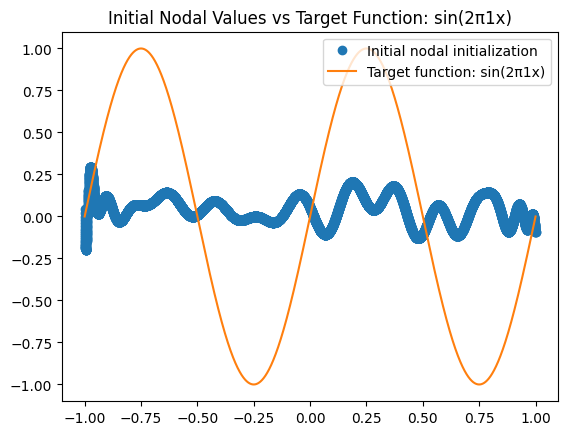

(2048, 1)


step 0, train loss=4.706e-01, eval rel L2=9.704e-01:   0%|          | 1/10000 [00:00<17:58,  9.27it/s]

Initial eval rel L2: 0.9704057726905164


step 9900, train loss=4.706e-01, eval rel L2=9.704e-01: 100%|██████████| 10000/10000 [00:06<00:00, 1482.75it/s]


Final eval rel L2: 0.9704057726905164


In [13]:
# Example: Train with SSBroyden optimizer
model_broyden, init_model_b, final_grad = run_experiment_broyden(
    N=32, k=1,
    steps=10000, 
    n_train=2048, 
    n_eval=10000, 
    use_exact_init=False,
    use_trainable_weights=True,
    rational_representation="standard",
    input_dependent_values=True,
    learn_query=False,
    learn_nodes=False,
    add_mlp=False,
    func_type = "sin",
    hdim=16,
    rng=nnx.Rngs(3)
)

In [ ]:
x_test = jnp.linspace(-1, 1, 1001).reshape(-1,1)

model_broyden.eval()

pred_post_attn = model_broyden.bary_attention(x_test)

# pred_norm = model_broyden.norm(pred_post_attn)

pred_post_mlp = model_broyden.mlp(pred_post_attn)

plt.semilogy(x_test, f_sin(x_test, 16) - pred_post_attn, label="post_attn error")
plt.semilogy(x_test, f_sin(x_test, 16) - (pred_post_mlp + pred_post_attn), label="final output")
plt.legend()

AttributeError: 'BarycentricAttention' object has no attribute 'bary_attention'

In [ ]:
# Visualization and comparison
def plot_results(models, labels, func_type="sin", k=16, n_plot=1000):
    """Plot comparison of models with flexible target function support"""
    x_plot = jnp.linspace(-1.0, 1.0, n_plot, dtype=DTYPE)
    
    # Get the appropriate target function
    target_func, func_name = get_target_function(func_type, k)
    y_true = target_func(x_plot)
    
    plt.figure(figsize=(12, 8))
    
    # Plot function approximations
    plt.subplot(2, 1, 1)
    plt.plot(x_plot, y_true, 'k-', label='True function', linewidth=2)
    
    for model, label in zip(models, labels):
        y_pred = model(x_plot.reshape(-1, 1)).ravel()
        rel_error = jnp.linalg.norm(y_pred - y_true) / jnp.linalg.norm(y_true)
        plt.plot(x_plot, y_pred, '--', label=f'{label} (rel L2: {rel_error:.2e})', alpha=0.8)
    
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Barycentric Attention Approximation of {func_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot errors
    plt.subplot(2, 1, 2)
    for model, label in zip(models, labels):
        y_pred = model(x_plot.reshape(-1, 1)).ravel()
        error = jnp.abs(y_pred - y_true)
        plt.semilogy(x_plot, error, label=f'{label} error')
    
    plt.xlabel('x')
    plt.ylabel('|Error|')
    plt.title('Absolute Error')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot comparison if both models are available
try:
    plot_results([init_model, model_broyden], ['Initial (exact)', 'SSBroyden trained'], func_type="sin", k=8)
except NameError:
    print("Run the training experiments first to generate models for comparison")

In [31]:
# Example: Train with Adam optimizer for comparison
model_adam, init_model = run_experiment_adam(
    N=96, k=1,
    steps=100000,
    n_train=2048,
    n_eval=10000,
    lr=1e-3,
    use_exact_init=False,
    use_trainable_weights=True,
    rational_representation="linear",
    input_dependent_values=True,
    learn_query=False,
    learn_nodes=False,
    add_mlp=False,
    func_type = "sin",
    hdim=8,
    optimizer_type="adam",
    rng=nnx.Rngs(42)
)

Training Barycentric Attention with ADAM optimizer
Using linear representation for the weights, target=sin(2π1x)
Using input-dependent values: V(x) = V_matrix * x + V_bias
Using random initialization


step 0, train loss=5.0901203e-01, eval rel L2=1.007e+00, lr 1.00e-03:   0%|          | 1/100000 [00:00<4:47:58,  5.79it/s]

Initial eval rel L2: 1.009209760836281


step 99000, train loss=1.1121848e-09, eval rel L2=4.811e-05, lr 4.87e-08: 100%|██████████| 100000/100000 [02:31<00:00, 662.07it/s]

Final eval rel L2: 4.809752805379808e-05


Training Barycentric Attention with ADAM optimizer
Using linear representation for the weights, target=sin(2π8x)
Using input-dependent values: V(x) = V_matrix * x + V_bias
Using exact function values for sin(2π8x) initialization
training:   0%|          | 0/100000 [00:00<?, ?it/s]Initial eval rel L2: 0.00012796663067663855
step 99000, train loss=3.8753001e-12, eval rel L2=2.733e-06, lr 4.87e-08: 100%|██████████| 100000/100000 [01:53<00:00, 877.76it/s]
Final eval rel L2: 2.732835742028769e-06

In [ ]:
model_adam.nodes - init_model.nodes

Array([ 6.77637902e-04, -3.87429642e-04, -8.90614827e-04,  1.53823941e-04,
        1.93947077e-05, -1.83354084e-04,  9.00467571e-04,  3.86299649e-04,
       -6.79404155e-04], dtype=float64)

In [ ]:
6x10^-9
6.3x10^-10

In [ ]:
model_adam.alpha

AttributeError: 'mini_transformer' object has no attribute 'alpha'

Comparing exact vs random initialization...
Training Barycentric Attention with N=128 nodes, k=8
Using standard rational representation
Using exact function values for initialization


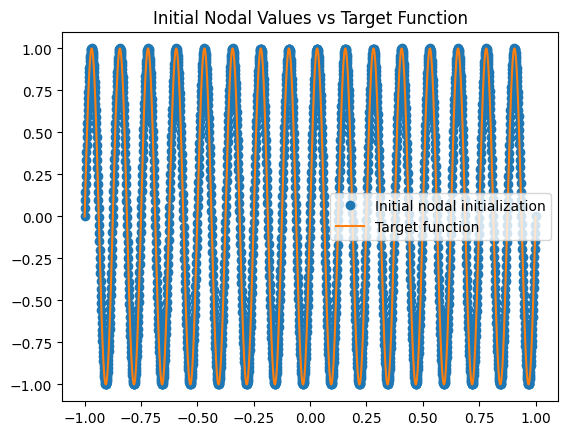

(1024, 1)


training:   0%|          | 0/2000 [00:00<?, ?it/s]

Initial eval rel L2: 2.565796564840591e-15


step 800, train loss=1.295e-30, eval rel L2=1.853e-15:  42%|████▏     | 843/2000 [00:18<00:25, 44.56it/s]


KeyboardInterrupt: 

In [ ]:
# Compare different initialization strategies
def compare_initialization_strategies(N=128, k=8, steps=2000):
    print("Comparing exact vs random initialization...")
    
    # Exact initialization
    model_exact, _ = run_experiment_broyden(
        N=N, k=k, steps=steps, use_exact_init=True, rng=nnx.Rngs(42)
    )
    
    # Random initialization  
    model_random, _ = run_experiment_broyden(
        N=N, k=k, steps=steps, use_exact_init=False, rng=nnx.Rngs(42)
    )
    
    return model_exact, model_random

# Uncomment to run comparison
model_exact, model_random = compare_initialization_strategies()
plot_results([model_exact, model_random], ['Exact init', 'Random init'], k=8)

In [94]:
# =========================
# Tensor-product second barycentric form
# =========================
import jax, jax.numpy as jnp
from flax import nnx
jax.config.update("jax_enable_x64", True)

DTYPE = jnp.float64

def _as_param_or_array(arr, learn: bool):
    arr = jnp.asarray(arr, dtype=DTYPE)
    return nnx.Param(arr) if learn else arr

def _get_array(x):
    # Works for nnx.Param or plain ndarray
    return x.value if isinstance(x, nnx.Param) else x

class TensorProductBarycentricAttention(nnx.Module):
    """
    d-D tensor-product second barycentric form.

    Nodes/weights:
      - nodes_list: list/tuple of length d; nodes_list[ℓ] has shape (Mℓ,)
      - w_list    : list/tuple of length d; each element is either:
           * a module with signature w(x_ℓ) -> (Mℓ,) or (B, Mℓ) (e.g. RationalBaryWeights),
           * or a constant weight array of shape (Mℓ,) (we’ll wrap it).

    Values:
      - V_init: array of shape (M0, M1, ..., M_{d-1}, D)
        (D is output dimension; D=1 gives scalar output with shape (B,1))

    Call:
      - x: shape (B, d)
      - returns y: shape (B, D)
    """
    nodes_list: tuple
    w_list: tuple
    V: nnx.Param

    def __init__(self,
                 nodes_list,               # sequence of 1D node arrays
                 w_list,                   # sequence of weight modules or arrays
                 V_init,                   # (M0,...,M_{d-1}, D)
                 *,
                 learn_nodes: bool | list[bool] = False,
                 rngs: nnx.Rngs = nnx.Rngs(0)):
        # Normalize inputs
        nodes_list = list(nodes_list)
        w_list = list(w_list)

        d = len(nodes_list)
        if isinstance(learn_nodes, bool):
            learn_nodes = [learn_nodes] * d

        # Store per-axis nodes (as Param if learnable)
        self.nodes_list = tuple(_as_param_or_array(nodes_list[ℓ], learn_nodes[ℓ]) for ℓ in range(d))

        # Wrap constant weights into callables so they match your 1D API
        wrapped_w = []
        for ℓ in range(d):
            wℓ = w_list[ℓ]
            if isinstance(wℓ, (RationalBaryWeights, LinearRationalBaryWeights, KernelRationalBaryWeights)):
                wrapped_w.append(wℓ)
            else:
                w_arr = jnp.asarray(wℓ, dtype=DTYPE)
                wrapped_w.append(lambda xs, w_arr=w_arr: w_arr)  # constant
        self.w_list = tuple(wrapped_w)

        # Store grid values (M0,...,M_{d-1}, D)
        V_init = jnp.asarray(V_init, dtype=DTYPE)
        self.V = nnx.Param(V_init)

    # ---- core: evaluate using sequential 1-D barycentric contractions
    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        """
        x: (B, d) or (B,) with d=1
        returns: (B, D)
        """
        x = jnp.asarray(x, dtype=DTYPE)
        if x.ndim == 1:
            x = x[:, None]
        B, d = x.shape

        # 1) compute 1-D lambda rows for each coordinate: lam_list[ℓ] has shape (B, Mℓ)
        lam_list = []
        for ℓ in range(d):
            nodesℓ = _get_array(self.nodes_list[ℓ])
            wℓ = self.w_list[ℓ]
            lam_ℓ = barycentric_lambdas_safe(x[:, ℓ], nodesℓ, wℓ)   # (B, Mℓ)
            lam_list.append(lam_ℓ)

        # 2) sequentially contract V over each axis with lam_list[ℓ]
        #    This computes r(x_b) = Σ_{j} (∏_ℓ lam^{(ℓ)}_{b, jℓ}) * V[j]
        #    We do it without materializing the full ∏ outer-product.
        A = self.V.value  # (M0, M1, ..., M_{d-1}, D)

        # Fold over dimensions in order: after each step, axis 0 is consumed
        # by contracting with lam_list[ℓ][b,:]. We batch the contraction via vmap.
        def eval_one(b):
            T = A
            for ℓ in range(d):
                lam = lam_list[ℓ][b]              # (Mℓ,)
                # Ensure contracting along axis 0: T has shape (Mℓ, <rest>...)
                # If we're at step ℓ>0, axis 0 *is* the next dimension by construction.
                T = jnp.tensordot(lam, T, axes=(0, 0))  # -> (<rest>..., D)
            return T  # (D,)

        y = jax.vmap(eval_one)(jnp.arange(B))     # (B, D)
        return y


In [95]:
def cheb_lobatto_axis(N: int):
    j = jnp.arange(N+1, dtype=DTYPE)
    x = jnp.cos(jnp.pi * j / N)
    delta = jnp.where((j==0) | (j==N), 0.5, 1.0)
    w = ((-1.0) ** j) * delta
    return x, w

def make_V_from_function(f, nodes_list, D: int = 1):
    """
    f: callable that accepts (x1, x2, ..., xd) -> R^D or scalar
    nodes_list: list of arrays per axis
    returns V with shape (M0,...,M_{d-1}, D)
    """
    grids = jnp.meshgrid(*nodes_list, indexing='ij')  # list of d arrays each (M0,...,Md-1)
    vals = f(*grids)                                  # shape (...,) or (..., D)
    vals = jnp.asarray(vals, dtype=DTYPE)
    if D == 1 and vals.ndim == len(nodes_list):
        vals = vals[..., None]
    return vals


In [101]:
# 2D example: f(x,y) = [sin(2πkx) * cos(2πky),  cos(2πkx) * sin(2πky)]
k = 4
def f2(x, y):
    f1 = jnp.sin(2*jnp.pi*k*x) * jnp.cos(2*jnp.pi*k*y)
    f2 = jnp.cos(2*jnp.pi*k*x) * jnp.sin(2*jnp.pi*k*y)
    return jnp.stack([f1, f2], axis=-1)  # (..., 2)

# per-axis nodes/weights + trainable per-axis weights
N0, N1 = 64, 64
x0, w0 = cheb_lobatto_axis(N0)
x1, w1 = cheb_lobatto_axis(N1)

w0_mod = RationalBaryWeights(N0, use_alpha=True)  # trainable 1D weights
w1_mod = RationalBaryWeights(N1, use_alpha=True)

V_init = make_V_from_function(f2, [x0, x1], D=2)  # (N0+1, N1+1, 2)

tp_layer = TensorProductBarycentricAttention(
    nodes_list=[x0, x1],
    w_list=[w0_mod, w1_mod],
    V_init=V_init,
    learn_nodes=False,    # set True to optimize nodes per axis
    rngs=nnx.Rngs(0)
)

# Evaluate
B = 1000
xy = jnp.stack([
    jnp.linspace(-1, 1, B),
    jnp.linspace(-1, 1, B)
], axis=1)
y_pred = tp_layer(xy)     # (B, 2)


In [102]:
y_pred

Array([[ 9.79717439e-16,  9.79717439e-16],
       [ 5.02309189e-02,  5.02309189e-02],
       [ 9.99535926e-02,  9.99535926e-02],
       ...,
       [-9.99535926e-02, -9.99535926e-02],
       [-5.02309189e-02, -5.02309189e-02],
       [-9.79717439e-16, -9.79717439e-16]], dtype=float64)

In [103]:
# =========================
# 2-D visualization helpers
# =========================
import numpy as np
import matplotlib.pyplot as plt

def eval_on_grid_2d(layer, f_true, xlims=(-1,1), ylims=(-1,1), res=256):
    """
    Evaluate a 2-D tensor-product barycentric layer and a reference function on a grid.

    Returns:
      X, Y     : (res,res) coordinate grids (numpy)
      Y_true   : (res,res,D)
      Y_pred   : (res,res,D)
      Y_abserr : (res,res,D)
    """
    xs = jnp.linspace(xlims[0], xlims[1], res, dtype=DTYPE)
    ys = jnp.linspace(ylims[0], ylims[1], res, dtype=DTYPE)
    X, Y = jnp.meshgrid(xs, ys, indexing='xy')          # (res,res)
    P = jnp.stack([X.ravel(), Y.ravel()], axis=1)       # (res*res, 2)

    # Model prediction on flattened grid, then reshape
    Y_pred = layer(P)                                   # (res*res, D) or (res*res,1)
    if Y_pred.ndim == 1:
        Y_pred = Y_pred[:, None]
    D = Y_pred.shape[1]
    Y_pred = Y_pred.reshape(res, res, D)

    # Ground truth on grid, then ensure (...,D)
    Y_true = f_true(X, Y)                               # (...,) or (...,D)
    Y_true = jnp.asarray(Y_true, dtype=DTYPE)
    if Y_true.ndim == 2:                                # scalar field
        Y_true = Y_true[..., None]

    Y_abserr = jnp.abs(Y_pred - Y_true)

    # Convert to numpy for matplotlib
    return (np.array(X), np.array(Y),
            np.array(Y_true), np.array(Y_pred), np.array(Y_abserr))

def plot_tp_barycentric_2d(layer, f_true, nodes_list,
                           xlims=(-1,1), ylims=(-1,1), res=256,
                           cmap='viridis', err_cmap='magma'):
    """
    Visualize a 2-D tensor-product barycentric layer vs a true function.

    nodes_list: [x_nodes, y_nodes] (1-D arrays for each axis)
    """
    assert len(nodes_list) == 2, "This helper is 2-D only (pass [x_nodes, y_nodes])."

    X, Y, Y_true, Y_pred, Y_abserr = eval_on_grid_2d(layer, f_true, xlims, ylims, res)
    D = Y_true.shape[-1]

    # Product grid node locations for overlay
    x_nodes = np.asarray(nodes_list[0])
    y_nodes = np.asarray(nodes_list[1])
    Xn, Yn = np.meshgrid(x_nodes, y_nodes, indexing='xy')
    node_xy = (Xn.ravel(), Yn.ravel())

    fig, axes = plt.subplots(3, D, figsize=(4.2*D, 10), constrained_layout=True)
    if D == 1:
        axes = np.asarray(axes).reshape(3,1)

    extent = [xlims[0], xlims[1], ylims[0], ylims[1]]

    for d in range(D):
        # Common vmin/vmax for true & pred per channel (for fair visual comparison)
        vmin = min(Y_true[..., d].min(), Y_pred[..., d].min())
        vmax = max(Y_true[..., d].max(), Y_pred[..., d].max())

        im0 = axes[0, d].imshow(Y_true[..., d], origin='lower', extent=extent,
                                aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
        axes[0, d].plot(*node_xy, 'k.', ms=1.0, alpha=0.5)
        axes[0, d].set_title(f"True (channel {d})")

        im1 = axes[1, d].imshow(Y_pred[..., d], origin='lower', extent=extent,
                                aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
        axes[1, d].plot(*node_xy, 'k.', ms=1.0, alpha=0.5)
        axes[1, d].set_title(f"Tensor-product barycentric (channel {d})")

        im2 = axes[2, d].imshow(Y_abserr[..., d], origin='lower', extent=extent,
                                aspect='auto', cmap=err_cmap)
        axes[2, d].plot(*node_xy, 'k.', ms=1.0, alpha=0.5)
        axes[2, d].set_title(f"|error| (channel {d})")

        for r in range(3):
            axes[r, d].set_xlabel("x")
            axes[r, d].set_ylabel("y")

        # Colorbars (one per row for readability)
        fig.colorbar(im0, ax=axes[0, d], fraction=0.046, pad=0.04)
        fig.colorbar(im1, ax=axes[1, d], fraction=0.046, pad=0.04)
        fig.colorbar(im2, ax=axes[2, d], fraction=0.046, pad=0.04)

    fig.suptitle("2-D tensor-product second barycentric: truth vs prediction vs |error|", y=1.02)
    return fig, axes


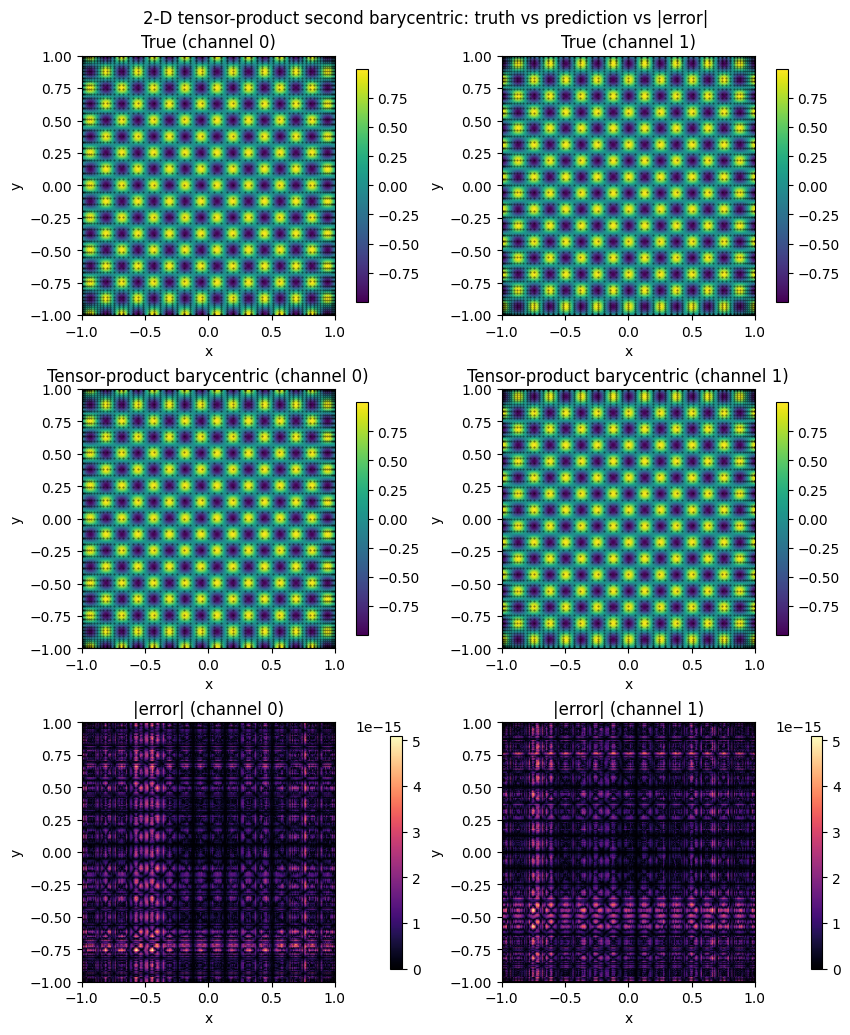

In [104]:
# Example target: 2-channel field
k = 4
def f2(x, y):
    f1 = jnp.sin(2*jnp.pi*k*x) * jnp.cos(2*jnp.pi*k*y)
    f2 = jnp.cos(2*jnp.pi*k*x) * jnp.sin(2*jnp.pi*k*y)
    return jnp.stack([f1, f2], axis=-1)  # (..., 2)

# Build nodes/weights/values as in the example you set up earlier...
x0, w0 = cheb_lobatto_axis(N0); x1, w1 = cheb_lobatto_axis(N1)
w0_mod = RationalBaryWeights(N0, use_alpha=True)
w1_mod = RationalBaryWeights(N1, use_alpha=True)
V_init = make_V_from_function(f2, [x0, x1], D=2)
tp_layer = TensorProductBarycentricAttention([x0, x1], [w0_mod, w1_mod], V_init)

# Plot
fig, axes = plot_tp_barycentric_2d(tp_layer, f2, [x0, x1], res=301)
plt.show()
